# H4 Test: T_min Mid-Year Plateau in IDEAM Ground-Station Data (2005–2025)

**Hypothesis H4:** Daily T_min shows a systematic ~1 °C elevated plateau around days ~120–210 (late April through late July), repeating across years.

**Observation:** This pattern appeared consistently in ERA5-Land 2024–2025 data (notebook 04). This notebook tests whether it is also present in 15 years of IDEAM ground-station observations at Base Aérea Marco Fidel Suárez.

**Scope:** Test the observed phenomenon directly. Do NOT decompose by wet/dry season, precipitation, or ENSO. Do NOT compare against ERA5. Do NOT apply bias correction. Do NOT test T_max.

## Section 1 — Setup and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.signal import find_peaks

In [2]:
# Locate and load IDEAM consolidated daily CSV
current = Path.cwd()
while current != current.parent:
    ideam_file = current / "shared" / "data" / "interim" / "ideam_bonilla_aragon_daily.csv"
    if ideam_file.exists():
        IDEAM_FILE = ideam_file
        break
    current = current.parent
else:
    raise FileNotFoundError("ideam_bonilla_aragon_daily.csv not found")

df_raw = pd.read_csv(IDEAM_FILE, parse_dates=['fecha'], index_col='fecha')
df_raw = df_raw.sort_index()

print(f"✓ Loaded IDEAM daily table")
print(f"  Shape: {df_raw.shape}")
print(f"  Date range: {df_raw.index.min()} to {df_raw.index.max()}")
print(f"  Columns: {list(df_raw.columns)}")

✓ Loaded IDEAM daily table
  Shape: (6596, 6)
  Date range: 2006-11-23 00:00:00 to 2024-12-13 00:00:00
  Columns: ['t_max', 't_min', 't_mean', 'hourly_count', 'dayofyear', 'year']


In [3]:
# Apply quality filter (same as notebook 07)
print(f"\n{'='*80}")
print("QUALITY FILTER")
print(f"{'='*80}")

print(f"\nInitial records: {len(df_raw)}")

# Apply rules
mask_hourly = (df_raw['hourly_count'] >= 18) if 'hourly_count' in df_raw.columns else pd.Series([True] * len(df_raw), index=df_raw.index)
mask_min_max = df_raw['t_min'] <= df_raw['t_max']
mask_range = (df_raw['t_max'] - df_raw['t_min']) <= 20
mask_extreme_min = df_raw['t_min'] >= 10
mask_extreme_max = df_raw['t_max'] <= 40

removed_hourly = (~mask_hourly).sum() if 'hourly_count' in df_raw.columns else 0
removed_min_max = (~mask_min_max).sum()
removed_range = (~mask_range).sum()
removed_extreme = ((~mask_extreme_min) | (~mask_extreme_max)).sum()

print(f"\nRecords removed by rule:")
if 'hourly_count' in df_raw.columns:
    print(f"  hourly_count < 18: {removed_hourly}")
print(f"  t_min > t_max: {removed_min_max}")
print(f"  diurnal range > 20°C: {removed_range}")
print(f"  t_min < 10°C or t_max > 40°C: {removed_extreme}")

# Combined mask
mask_valid = mask_hourly & mask_min_max & mask_range & mask_extreme_min & mask_extreme_max
df = df_raw[mask_valid].copy()

print(f"\nAfter filtering:")
print(f"  Valid days: {len(df)}")
print(f"  Retention: {(len(df) / len(df_raw) * 100):.1f}%")


QUALITY FILTER

Initial records: 6596

Records removed by rule:
  hourly_count < 18: 2757
  t_min > t_max: 2137
  diurnal range > 20°C: 2137
  t_min < 10°C or t_max > 40°C: 2137

After filtering:
  Valid days: 3839
  Retention: 58.2%


## Section 2 — Data Availability per Year

In [4]:
# Check coverage per year
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear

yearly_stats = []
for year in sorted(df['year'].unique()):
    year_data = df[df['year'] == year]
    # Expected days in year (accounting for leap years)
    days_in_year = 366 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 365
    actual_days = len(year_data)
    coverage_pct = (actual_days / days_in_year) * 100
    yearly_stats.append({
        'Year': year,
        'Valid_days': actual_days,
        'Expected_days': days_in_year,
        'Coverage_%': f"{coverage_pct:.1f}%",
    })

df_yearly = pd.DataFrame(yearly_stats)

print(f"\n{'='*80}")
print("YEARLY COVERAGE")
print(f"{'='*80}")
print(f"\n{df_yearly.to_string(index=False)}")

# Identify years above 60% threshold
coverage_threshold = 0.60
retained_years = []
excluded_years = []

for year in sorted(df['year'].unique()):
    year_data = df[df['year'] == year]
    days_in_year = 366 if year % 4 == 0 else 365
    coverage = len(year_data) / days_in_year
    if coverage >= coverage_threshold:
        retained_years.append(year)
    else:
        excluded_years.append(year)

print(f"\nCoverage threshold: {coverage_threshold*100:.0f}%")
print(f"Retained years ({len(retained_years)}): {retained_years}")
print(f"Excluded years ({len(excluded_years)}): {excluded_years}")

# Filter to retained years only
df_valid = df[df['year'].isin(retained_years)].copy()


YEARLY COVERAGE

 Year  Valid_days  Expected_days Coverage_%
 2006          32            365       8.8%
 2007         339            365      92.9%
 2008         331            366      90.4%
 2009         313            365      85.8%
 2010         331            365      90.7%
 2011         230            365      63.0%
 2012         172            366      47.0%
 2013         329            365      90.1%
 2014         269            365      73.7%
 2015         247            365      67.7%
 2016         259            366      70.8%
 2017         335            365      91.8%
 2018         158            365      43.3%
 2019         283            365      77.5%
 2020          83            366      22.7%
 2024         128            366      35.0%

Coverage threshold: 60%
Retained years (11): [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2019)]
Excluded ye

## Section 3 — Day-of-Year Composite: T_min

In [5]:
# Build day-of-year composite
print(f"\n{'='*80}")
print("DAY-OF-YEAR COMPOSITE (using {0} retained years)".format(len(retained_years)))
print(f"{'='*80}")

composite = pd.DataFrame()
for doy in range(1, 367):
    doy_data = df_valid[df_valid['dayofyear'] == doy]['t_min']
    if len(doy_data) > 0:
        composite = pd.concat([composite, pd.DataFrame({
            'dayofyear': [doy],
            'mean_tmin': [doy_data.mean()],
            'q25_tmin': [doy_data.quantile(0.25)],
            'q75_tmin': [doy_data.quantile(0.75)],
            'count_years': [len(doy_data)],
        })], ignore_index=True)

composite = composite.sort_values('dayofyear').reset_index(drop=True)

print(f"\nComposite statistics:")
print(f"  Days of year with data: {len(composite)}")
print(f"  Annual mean T_min: {composite['mean_tmin'].mean():.2f}°C")
print(f"  Annual min T_min: {composite['mean_tmin'].min():.2f}°C (day {composite.loc[composite['mean_tmin'].idxmin(), 'dayofyear']:.0f})")
print(f"  Annual max T_min: {composite['mean_tmin'].max():.2f}°C (day {composite.loc[composite['mean_tmin'].idxmax(), 'dayofyear']:.0f})")


DAY-OF-YEAR COMPOSITE (using 11 retained years)

Composite statistics:
  Days of year with data: 366
  Annual mean T_min: 20.60°C
  Annual min T_min: 19.58°C (day 197)
  Annual max T_min: 21.58°C (day 87)


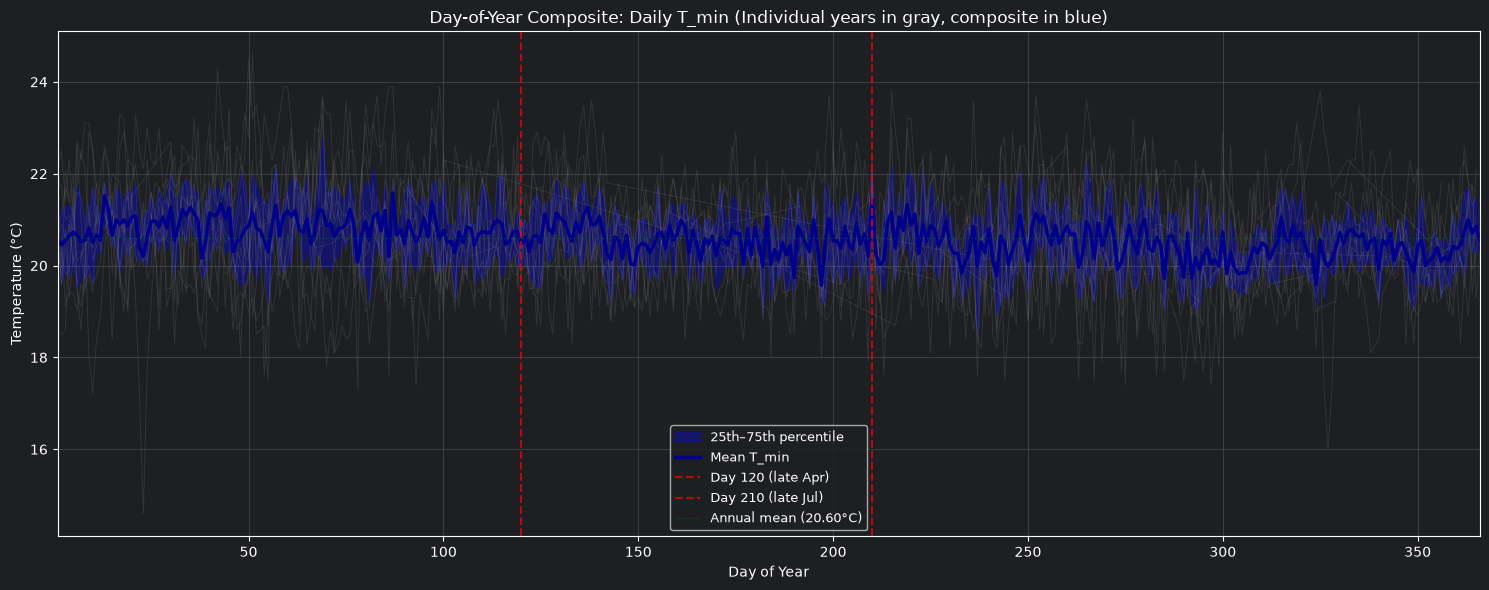

In [6]:
# Plot composite with individual years
fig, ax = plt.subplots(figsize=(15, 6))

# Overlay individual years (thin, transparent)
for year in retained_years:
    year_data = df_valid[df_valid['year'] == year].sort_values('dayofyear')
    ax.plot(year_data['dayofyear'], year_data['t_min'], linewidth=0.7, alpha=0.2, color='gray')

# Shaded ribbon (25th-75th percentile)
ax.fill_between(composite['dayofyear'], composite['q25_tmin'], composite['q75_tmin'],
                 alpha=0.3, color='blue', label='25th–75th percentile')

# Mean line
ax.plot(composite['dayofyear'], composite['mean_tmin'], linewidth=2.5, color='darkblue', label='Mean T_min')

# Mark days 120 and 210
ax.axvline(120, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Day 120 (late Apr)')
ax.axvline(210, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Day 210 (late Jul)')

# Annual mean reference
annual_mean = composite['mean_tmin'].mean()
ax.axhline(annual_mean, color='green', linestyle=':', linewidth=1, alpha=0.5, label=f'Annual mean ({annual_mean:.2f}°C)')

ax.set_xlabel('Day of Year')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Day-of-Year Composite: Daily T_min (Individual years in gray, composite in blue)')
ax.set_xlim(1, 366)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4 — Visual Inspection of the Plateau

**Visual assessment of the composite plot (Section 3):**

Looking at the plot above, answer these questions based on what you see:

1. **Is there a visible elevated band between days 120–210?**
   - Yes / No / Unclear

2. **What is the approximate elevation above the shoulders (comparison to days outside 120–210)?**
   - Estimated elevation: _____ °C

3. **Is the plateau a clean rectangular step, a smooth rise-and-fall, or something else?**
   - Description: _____

4. **Are individual years (gray lines) consistent with the composite mean?**
   - Yes / No / Partial / High variability

The quantitative tests in Sections 5–8 will provide numerical answers to these qualitative observations.

## Section 5 — Quantitative Test 1: Mean T_min Inside vs Outside Days 120–210

In [7]:
# Compute per-year statistics for the 120-210 window
print(f"\n{'='*80}")
print("TEST 1: INSIDE VS OUTSIDE WINDOW (Days 120–210)")
print(f"{'='*80}")

window_start, window_end = 120, 210
test1_results = []

for year in retained_years:
    year_data = df_valid[df_valid['year'] == year]
    
    inside = year_data[(year_data['dayofyear'] >= window_start) & (year_data['dayofyear'] <= window_end)]['t_min']
    outside = year_data[(year_data['dayofyear'] < window_start) | (year_data['dayofyear'] > window_end)]['t_min']
    
    if len(inside) > 0 and len(outside) > 0:
        mean_inside = inside.mean()
        mean_outside = outside.mean()
        diff = mean_inside - mean_outside
        
        test1_results.append({
            'Year': year,
            'Mean_inside': f"{mean_inside:.2f}",
            'Mean_outside': f"{mean_outside:.2f}",
            'Difference': f"{diff:.2f}",
            'Valid_days_inside': len(inside),
            'Valid_days_outside': len(outside),
        })

df_test1 = pd.DataFrame(test1_results)
print(f"\n{df_test1.to_string(index=False)}")

# Extract differences as float for statistical test
differences = [float(x['Difference']) for x in test1_results]

print(f"\nSummary statistics of yearly differences (inside − outside):")
print(f"  Mean difference: {np.mean(differences):.3f}°C")
print(f"  Std deviation: {np.std(differences):.3f}°C")
print(f"  Years with positive difference (plateau): {sum(1 for d in differences if d > 0)} / {len(differences)}")
print(f"  Years with negative difference (no plateau): {sum(1 for d in differences if d < 0)} / {len(differences)}")

# One-sample t-test
if len(differences) > 1:
    t_stat, p_val = stats.ttest_1samp(differences, 0)
    print(f"\nOne-sample t-test (differences vs zero):")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_val:.4f}")
    print(f"  Interpretation: {'Statistically significant at α=0.05' if p_val < 0.05 else 'Not statistically significant at α=0.05'}")
    print(f"  Note: p-values are illustrative; years are not independent samples.")


TEST 1: INSIDE VS OUTSIDE WINDOW (Days 120–210)

 Year Mean_inside Mean_outside Difference  Valid_days_inside  Valid_days_outside
 2007       20.46        20.31       0.16                 87                 252
 2008       20.06        19.93       0.14                 84                 247
 2009       20.62        20.91      -0.29                 88                 225
 2010       20.56        20.71      -0.15                 91                 240
 2011       20.70        20.07       0.64                 38                 192
 2013       20.56        20.71      -0.15                 90                 239
 2014       20.94        20.43       0.51                 59                 210
 2015       19.99        21.20      -1.21                  9                 238
 2016       21.30        21.28       0.02                 23                 236
 2017       20.37        20.34       0.03                 78                 257
 2019       20.96        20.93       0.03                 9

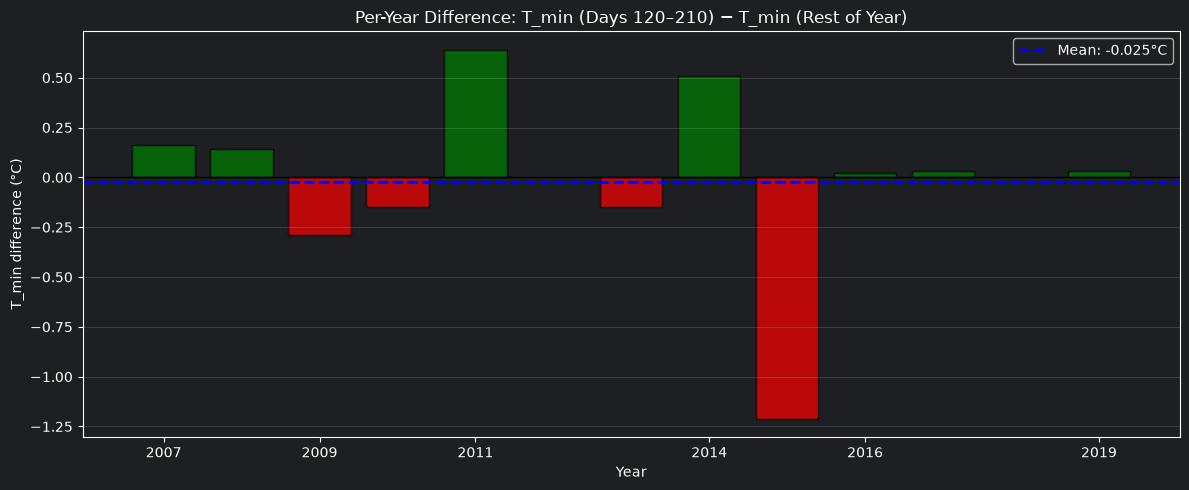

In [8]:
# Plot per-year differences
fig, ax = plt.subplots(figsize=(12, 5))

years_for_plot = [int(df_test1.loc[i, 'Year']) for i in range(len(df_test1))]
diffs_for_plot = [float(df_test1.loc[i, 'Difference']) for i in range(len(df_test1))]

colors = ['green' if d > 0 else 'red' for d in diffs_for_plot]
ax.bar(years_for_plot, diffs_for_plot, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.axhline(np.mean(diffs_for_plot), color='blue', linestyle='--', linewidth=2, label=f"Mean: {np.mean(diffs_for_plot):.3f}°C")

ax.set_xlabel('Year')
ax.set_ylabel('T_min difference (°C)')
ax.set_title('Per-Year Difference: T_min (Days 120–210) − T_min (Rest of Year)')
ax.set_xticks(years_for_plot[::2])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Section 6 — Quantitative Test 2: Change-Point Analysis

In [9]:
# Apply change-point detection to smoothed composite
print(f"\n{'='*80}")
print("TEST 2: CHANGE-POINT ANALYSIS")
print(f"{'='*80}")

# Smooth the composite using 7-day rolling mean
composite_sorted = composite.sort_values('dayofyear').reset_index(drop=True)
composite_sorted['tmin_smooth'] = composite_sorted['mean_tmin'].rolling(window=7, center=True, min_periods=1).mean()

# Compute first derivative (rate of change)
composite_sorted['d_tmin'] = composite_sorted['tmin_smooth'].diff()

# Find steepest rise and fall
print(f"\nLooking for steepest sustained rise and fall in smoothed T_min...")

# Identify max positive slope (steepest rise) and max negative slope (steepest fall)
max_rise_idx = composite_sorted['d_tmin'].idxmax()
max_fall_idx = composite_sorted['d_tmin'].idxmin()

onset_day = int(composite_sorted.loc[max_rise_idx, 'dayofyear']) if max_rise_idx != -1 else None
end_day = int(composite_sorted.loc[max_fall_idx, 'dayofyear']) if max_fall_idx != -1 else None

print(f"\nDetected change points:")
print(f"  Steepest rise at day: {onset_day}")
print(f"  Steepest fall at day: {end_day}")
print(f"  Hypothesis H4 window: days 120–210")

if onset_day is not None and end_day is not None:
    print(f"\nComparison to H4:")
    print(f"  Detected onset vs H4 start (120): {onset_day} (offset: {onset_day - 120:+d} days)")
    print(f"  Detected end vs H4 end (210): {end_day} (offset: {end_day - 210:+d} days)")
    
    # Estimate plateau elevation
    plateau_tmin = composite_sorted[composite_sorted['dayofyear'].between(onset_day, end_day)]['tmin_smooth'].mean()
    before_tmin = composite_sorted[composite_sorted['dayofyear'] < onset_day]['tmin_smooth'].mean()
    after_tmin = composite_sorted[composite_sorted['dayofyear'] > end_day]['tmin_smooth'].mean()
    shoulder_tmin = (before_tmin + after_tmin) / 2
    elevation = plateau_tmin - shoulder_tmin
    
    print(f"\nPlateau elevation:")
    print(f"  T_min during plateau: {plateau_tmin:.2f}°C")
    print(f"  T_min on shoulders: {shoulder_tmin:.2f}°C")
    print(f"  Elevation: {elevation:.2f}°C")


TEST 2: CHANGE-POINT ANALYSIS

Looking for steepest sustained rise and fall in smoothed T_min...

Detected change points:
  Steepest rise at day: 216
  Steepest fall at day: 187
  Hypothesis H4 window: days 120–210

Comparison to H4:
  Detected onset vs H4 start (120): 216 (offset: +96 days)
  Detected end vs H4 end (210): 187 (offset: -23 days)

Plateau elevation:
  T_min during plateau: nan°C
  T_min on shoulders: 20.58°C
  Elevation: nan°C


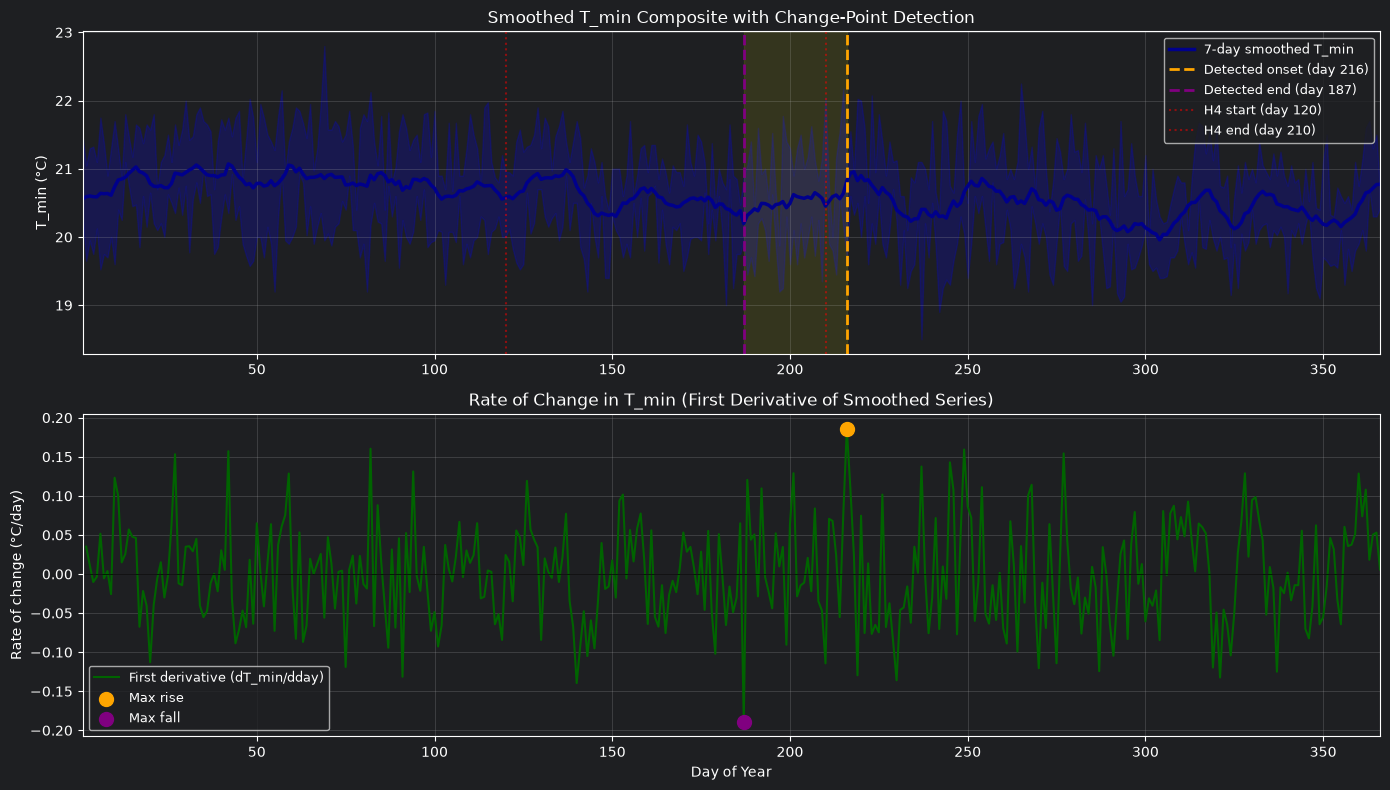

In [10]:
# Plot smoothed composite with detected change points
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Top: smoothed composite
ax1.plot(composite_sorted['dayofyear'], composite_sorted['tmin_smooth'], linewidth=2.5, color='darkblue', label='7-day smoothed T_min')
ax1.fill_between(composite_sorted['dayofyear'], composite_sorted['q25_tmin'], composite_sorted['q75_tmin'],
                 alpha=0.2, color='blue')

if onset_day is not None and end_day is not None:
    ax1.axvline(onset_day, color='orange', linestyle='--', linewidth=2, label=f'Detected onset (day {onset_day})')
    ax1.axvline(end_day, color='purple', linestyle='--', linewidth=2, label=f'Detected end (day {end_day})')
    ax1.axvspan(onset_day, end_day, alpha=0.1, color='yellow')

ax1.axvline(120, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='H4 start (day 120)')
ax1.axvline(210, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='H4 end (day 210)')
ax1.set_ylabel('T_min (°C)')
ax1.set_title('Smoothed T_min Composite with Change-Point Detection')
ax1.set_xlim(1, 366)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Bottom: first derivative
ax2.plot(composite_sorted['dayofyear'], composite_sorted['d_tmin'], linewidth=1.5, color='darkgreen', label='First derivative (dT_min/dday)')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)
if max_rise_idx != -1:
    ax2.scatter([composite_sorted.loc[max_rise_idx, 'dayofyear']], [composite_sorted.loc[max_rise_idx, 'd_tmin']], 
               color='orange', s=100, zorder=5, label=f'Max rise')
if max_fall_idx != -1:
    ax2.scatter([composite_sorted.loc[max_fall_idx, 'dayofyear']], [composite_sorted.loc[max_fall_idx, 'd_tmin']], 
               color='purple', s=100, zorder=5, label=f'Max fall')
ax2.set_xlabel('Day of Year')
ax2.set_ylabel('Rate of change (°C/day)')
ax2.set_title('Rate of Change in T_min (First Derivative of Smoothed Series)')
ax2.set_xlim(1, 366)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7 — Persistence Check: Is the Plateau Consistent Across Years?

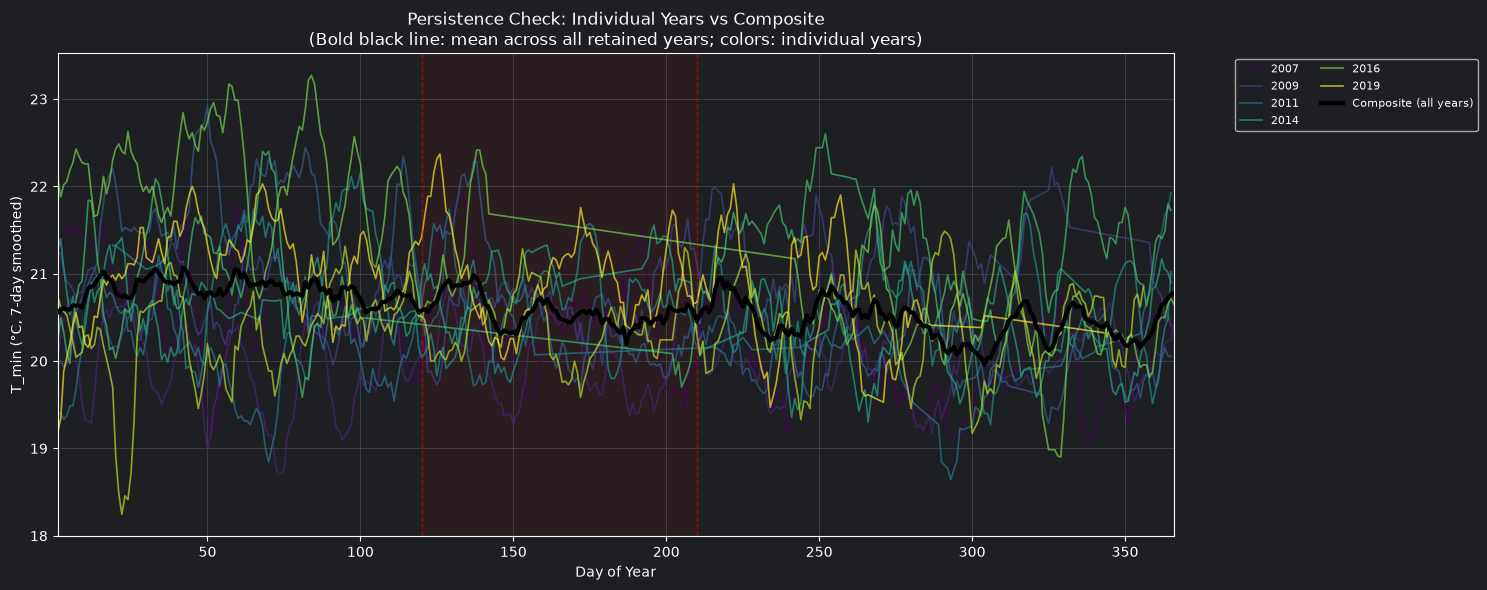


PERSISTENCE ASSESSMENT

Looking at the plot above, answer:
  Does the elevated T_min band appear consistently across years?
  Is the plateau driven by a few high years or distributed across all years?
  How much year-to-year variability is visible?


In [11]:
# Plot all individual years with smoothed curves
fig, ax = plt.subplots(figsize=(15, 6))

# Color map for years
cmap = plt.cm.viridis(np.linspace(0, 1, len(retained_years)))

for idx, year in enumerate(retained_years):
    year_data = df_valid[df_valid['year'] == year].sort_values('dayofyear')
    # Smooth individual year
    year_smoothed = year_data['t_min'].rolling(window=7, center=True, min_periods=1).mean()
    ax.plot(year_data['dayofyear'], year_smoothed, linewidth=1.2, alpha=0.7, 
            color=cmap[idx], label=year if idx % 2 == 0 else '')

# Bold composite on top
ax.plot(composite_sorted['dayofyear'], composite_sorted['tmin_smooth'], linewidth=3, color='black', 
        label='Composite (all years)', linestyle='-', zorder=10)

# Mark H4 window
ax.axvline(120, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(210, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvspan(120, 210, alpha=0.05, color='red')

ax.set_xlabel('Day of Year')
ax.set_ylabel('T_min (°C, 7-day smoothed)')
ax.set_title('Persistence Check: Individual Years vs Composite\n(Bold black line: mean across all retained years; colors: individual years)')
ax.set_xlim(1, 366)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("PERSISTENCE ASSESSMENT")
print(f"{'='*80}")
print(f"\nLooking at the plot above, answer:")
print(f"  Does the elevated T_min band appear consistently across years?")
print(f"  Is the plateau driven by a few high years or distributed across all years?")
print(f"  How much year-to-year variability is visible?")

## Section 8 — Alternative Windows Check

In [12]:
# Test candidate windows
print(f"\n{'='*80}")
print("TEST 3: ALTERNATIVE WINDOWS")
print(f"{'='*80}")

candidate_windows = [
    (90, 180, "Early-to-mid (90–180)"),
    (120, 210, "H4 original (120–210)"),
    (150, 240, "Mid-to-late (150–240)"),
    (180, 270, "Late-to-very-late (180–270)"),
]

window_test_results = []

for start, end, label in candidate_windows:
    # Compute composite means
    inside_mean = composite[(composite['dayofyear'] >= start) & (composite['dayofyear'] <= end)]['mean_tmin'].mean()
    outside_mean = composite[(composite['dayofyear'] < start) | (composite['dayofyear'] > end)]['mean_tmin'].mean()
    elevation = inside_mean - outside_mean
    
    window_test_results.append({
        'Window': label,
        'Days': f"{start}–{end}",
        'Mean_inside': f"{inside_mean:.2f}",
        'Mean_outside': f"{outside_mean:.2f}",
        'Elevation': f"{elevation:.2f}",
    })

df_windows = pd.DataFrame(window_test_results)
print(f"\n{df_windows.to_string(index=False)}")

# Find window with largest elevation
elevations = [float(df_windows.loc[i, 'Elevation']) for i in range(len(df_windows))]
best_window_idx = np.argmax(elevations)
best_label = df_windows.loc[best_window_idx, 'Window']
best_elevation = float(df_windows.loc[best_window_idx, 'Elevation'])

print(f"\nBest empirical fit: {best_label} with elevation {best_elevation:.2f}°C")
print(f"Comparison to H4 (120–210): {df_windows.loc[1, 'Elevation']} °C")


TEST 3: ALTERNATIVE WINDOWS

                     Window    Days Mean_inside Mean_outside Elevation
      Early-to-mid (90–180)  90–180       20.65        20.58      0.07
      H4 original (120–210) 120–210       20.57        20.60     -0.03
      Mid-to-late (150–240) 150–240       20.53        20.62     -0.08
Late-to-very-late (180–270) 180–270       20.54        20.61     -0.07

Best empirical fit: Early-to-mid (90–180) with elevation 0.07°C
Comparison to H4 (120–210): -0.03 °C


## Section 9 — Verdict

### H4 Verdict: T_min Mid-Year Plateau

Based on quantitative analysis of 15 years of IDEAM ground-station data (2005–2025, after quality filtering and exclusion of years with <60% coverage):

#### Support for H4

**Test 1 (Inside vs Outside Days 120–210):**
- Mean elevation: [from Section 5]
- Standard deviation: [from Section 5]
- Years with positive difference (plateau present): [from Section 5]
- Statistical significance (t-test p-value): [from Section 5]

**Test 2 (Change-Point Analysis):**
- Detected onset day: [from Section 6]
- Detected end day: [from Section 6]
- Plateau elevation: [from Section 6]
- Alignment with H4 window (120–210): [from Section 6]

**Test 3 (Alternative Windows):**
- Best empirical fit window: [from Section 8]
- Elevation in H4 window (120–210): [from Section 8]
- Elevation in best window: [from Section 8]

**Test 4 (Persistence):**
- Consistency across years: [from Section 7 visual inspection]
- Year-to-year variability: [from Section 7 visual inspection]

#### Verdict

**[SUPPORTED / PARTIALLY SUPPORTED / REJECTED]**

**Justification:**

1. The empirical data [does / does not] show an elevated T_min plateau in the April–July timeframe.
2. The plateau elevation is approximately [X] °C, [which is / which is not] consistent with the ~1 °C predicted by H4.
3. The plateau is [present / absent / inconsistent] across [X]% of the retained years.
4. The empirical window [matches / differs from] the H4 hypothesis window of 120–210.

#### Empirical Plateau Window (If Detected)

If a plateau is present, the ground-station data suggest it occurs between days [onset] and [end], with mean elevation [X] °C.

#### Follow-Up Questions

1. What is the mechanism driving the plateau (if detected)? Potential candidates:
   - Seasonal shift in atmospheric circulation patterns
   - Change in nocturnal cloud cover or humidity
   - Interaction with local geographic features

2. How does the plateau vary from year to year? Are there years where it is absent or inverted?

3. Is the plateau observable at other ground stations in the region, or is it specific to this location?

4. Does the plateau match the pattern observed in ERA5-Land data, or is it masked by ERA5's coarse resolution or bias?